<a href="https://colab.research.google.com/github/Aar1yan/-Superstore-Sales-Analysis/blob/main/Superstore_Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [185]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

In [186]:
df=pd.read_excel("sample_-_superstore.xls")

In [187]:
df.shape

(10194, 21)

In [188]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.45,2,0.20,5.55
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.54,2,0.80,-5.49
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.78,3,0.20,4.27
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.74,3,0.20,-64.77
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.54,3,0.20,4.88


In [189]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  object        
 2   Order Date      10194 non-null  datetime64[ns]
 3   Ship Date       10194 non-null  datetime64[ns]
 4   Ship Mode       10194 non-null  object        
 5   Customer ID     10194 non-null  object        
 6   Customer Name   10194 non-null  object        
 7   Segment         10194 non-null  object        
 8   Country/Region  10194 non-null  object        
 9   City            10194 non-null  object        
 10  State/Province  10194 non-null  object        
 11  Postal Code     10194 non-null  object        
 12  Region          10194 non-null  object        
 13  Product ID      10194 non-null  object        
 14  Category        10194 non-null  object        
 15  Su

In [190]:
df.describe()

,Row ID,Order Date,Ship Date,Sales,Quantity,Discount,Profit
count,"10,194.00",10194,10194,"10,194.00","10,194.00","10,194.00","10,194.00"
mean,"5,097.50",2025-04-29 11:48:25.002942720,2025-05-03 10:52:45.626839296,228.23,3.79,0.16,28.67
min,1.00,2023-01-03 00:00:00,2023-01-07 00:00:00,0.44,1.00,0.00,"-6,599.98"
25%,"2,549.25",2024-05-14 00:00:00,2024-05-19 00:00:00,17.22,2.00,0.00,1.76
50%,"5,097.50",2025-06-25 00:00:00,2025-06-28 00:00:00,53.91,3.00,0.20,8.69
75%,"7,645.75",2026-05-14 00:00:00,2026-05-18 00:00:00,209.50,5.00,0.20,29.30
max,"10,194.00",2026-12-30 00:00:00,2027-01-05 00:00:00,"22,638.48",14.00,0.80,"8,399.98"
std,"2,942.90",NaN,NaN,619.91,2.23,0.21,232.47


In [191]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country/Region,0
City,0


In [192]:
df.duplicated().sum()

np.int64(0)

In [193]:
df['Year']=df['Order Date'].dt.year.astype(int)
df['Month']=df['Order Date'].dt.month.astype(int)
df['Month_name']=df['Order Date'].dt.month_name()
df['Day']=df['Order Date'].dt.day
df['quarter']=df['Order Date'].dt.quarter.astype(int)

In [194]:
(df['Sales']==0).sum()

np.int64(0)

In [195]:
(df['Profit']<0).sum()

np.int64(1901)

In [196]:
df['Profit_Margin %']=(df['Profit']/df['Sales'])*100

In [197]:
df.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Sales,Quantity,Discount,Profit,Year,Month,Month_name,Day,quarter,Profit_Margin %
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,16.45,2,0.20,5.55,2023,1,January,3,1,33.75
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,3.54,2,0.80,-5.49,2023,1,January,4,1,-155.00
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,11.78,3,0.20,4.27,2023,1,January,4,1,36.25


#                                     **##SALES ANALYSIS##**

In [198]:
Category_sales=df.groupby('Category')['Sales'].sum()
Category_sales.sort_values(ascending=False)

,Sales
Category,
Technology,"839,893.28"
Furniture,"754,747.76"
Office Supplies,"731,893.31"


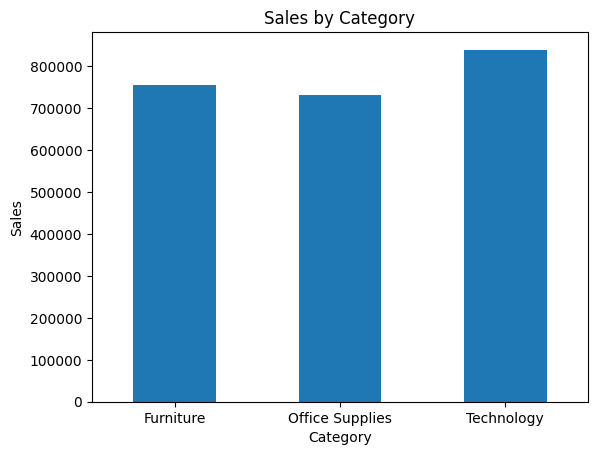

In [199]:
Category_sales.plot(kind="bar")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.show()

# **Finding**

Technology generated the highest total sales among the three product categories, while Office Supplies generated the lowest total sales. Furniture ranked between the two categories.

# **Business Insight**

Technology appears to be the strongest category in terms of revenue generation. The company should investigate the factors driving its higher sales and evaluate whether similar strategies can be applied to the lower-performing categories.

In [200]:
Month_Sales=df.groupby(['Month','Month_name'])['Sales'].sum()
Month_Sales

,,Sales
Month,Month_name,
1,January,"96,069.52"
2,February,"59,751.25"
3,March,"210,672.09"
4,April,"138,098.75"
5,May,"158,765.03"
6,June,"153,460.00"
7,July,"149,001.71"
8,August,"161,821.92"
9,September,"308,883.67"


In [201]:
Month_Sales = Month_Sales.droplevel("Month")
Month_Sales

,Sales
Month_name,
January,"96,069.52"
February,"59,751.25"
March,"210,672.09"
April,"138,098.75"
May,"158,765.03"
June,"153,460.00"
July,"149,001.71"
August,"161,821.92"
September,"308,883.67"


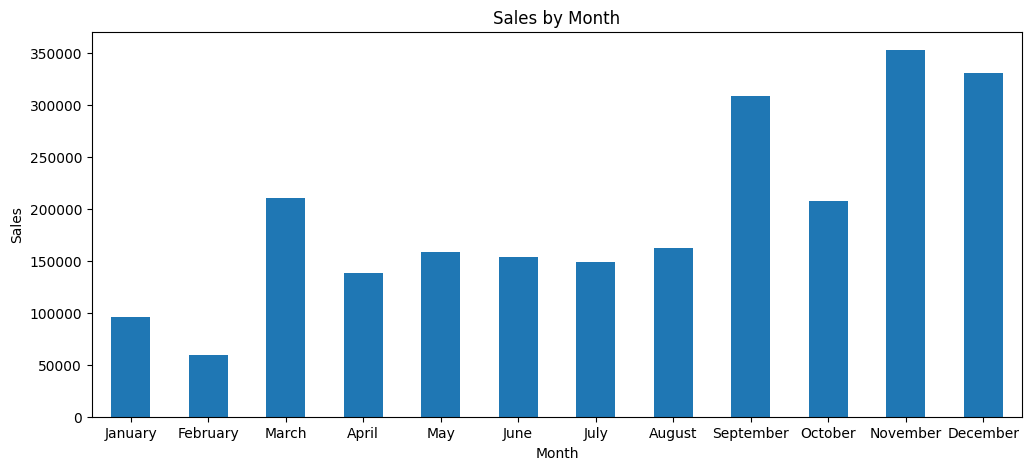

In [202]:
plt.figure(figsize=(12,5))
Month_Sales.plot(kind="bar")
plt.title("Sales by Month")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.show()

# **Finding**

November recorded the highest monthly sales, followed by December and September. February recorded the lowest sales, while January and April also had relatively low sales.

# **Business Insight**

Sales show noticeable seasonal variation, with substantially higher sales toward the end of the year. Management should investigate the factors contributing to the strong performance in November and December and consider whether inventory, promotions, and marketing efforts should be adjusted to capitalize on these periods.

In [203]:
Year_Sales=df.groupby('Year')['Sales'].sum()
Year_Sales

,Sales
Year,
2023,"494,040.21"
2024,"472,993.03"
2025,"613,933.58"
2026,"745,567.53"


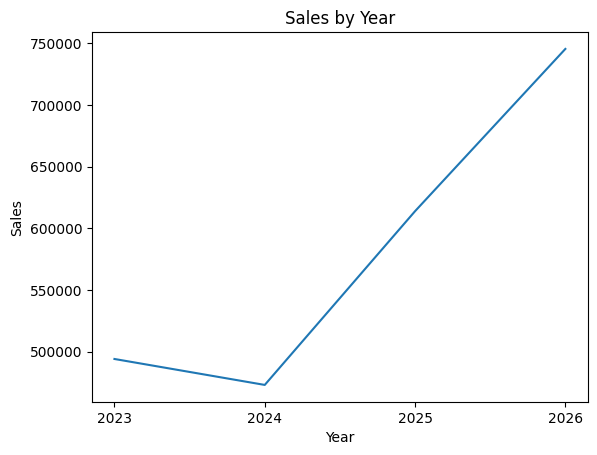

In [204]:
Year_Sales.plot(kind="line")
plt.title("Sales by Year")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.xticks(Year_Sales.index)
plt.show()

# **Finding**

Sales decreased slightly from 2023 to 2024, but then increased significantly in 2025 and 2026. The highest total sales were recorded in 2026, while 2024 had the lowest.

# **Business Insight**

The overall trend indicates strong sales growth after 2024. However, the 2026 figure should be interpreted cautiously if the dataset does not contain the full year, since an incomplete year cannot be fairly compared with complete years.

# **##CUSTOMER ANALYSIS##**

In [205]:
CUSTOMER_SALES=df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)
CUSTOMER_SALES

,Sales
Customer Name,
Sean Miller,"25,043.05"
Tamara Chand,"19,052.22"
Raymond Buch,"15,117.34"
Tom Ashbrook,"14,595.62"
Adrian Barton,"14,473.57"
Ken Lonsdale,"14,175.23"
Sanjit Chand,"14,142.33"
Hunter Lopez,"12,873.30"
Sanjit Engle,"12,209.44"


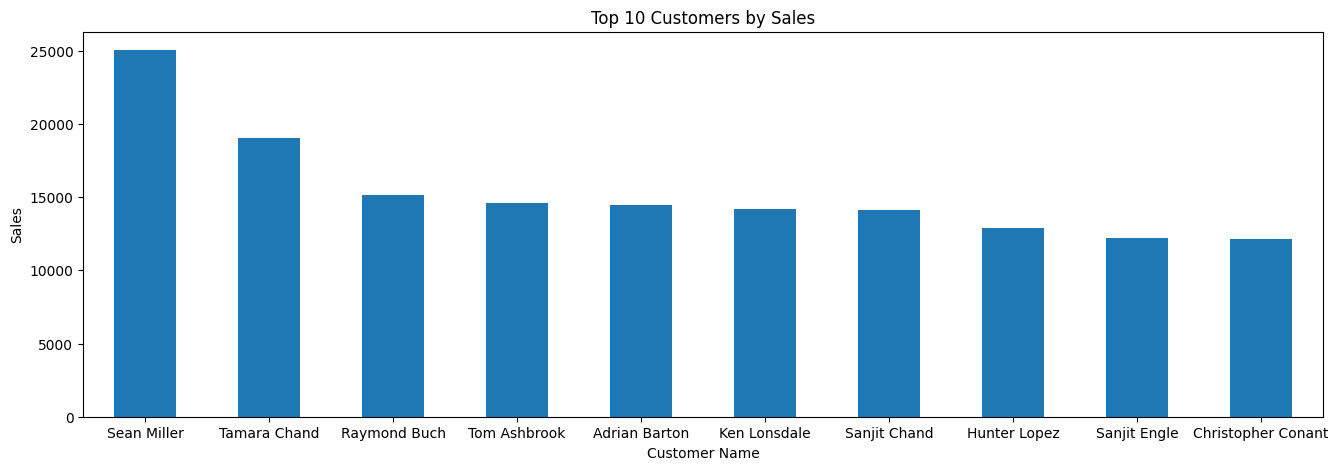

In [206]:
plt.figure(figsize=(16,5))
CUSTOMER_SALES.plot(kind="bar")
plt.title("Top 10 Customers by Sales")
plt.xlabel("Customer Name")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.show()

# **Finding**

Sean Miller generated the highest total sales among the top 10 customers, with approximately $25,043 in sales. Tamara Chand ranked second with approximately $19,052, while Christopher Conant had the lowest sales among the top 10 at approximately $12,129.

# **Business Insight**

A small group of high-value customers contributes significantly to sales. The company should prioritize retaining these customers through strong customer service and targeted offers while identifying opportunities to increase spending among other customers.

In [207]:
Most_Orders_Customer=df.groupby('Customer Name')['Order ID'].count().sort_values(ascending=False).head(10)
Most_Orders_Customer

,Order ID
Customer Name,
William Brown,41
Ben Ferrer,37
Greg Guthrie,36
Paul Prost,34
Jane Waco,34
John Lee,34
Xylona Preis,34
Matt Abelman,34
Seth Vernon,32


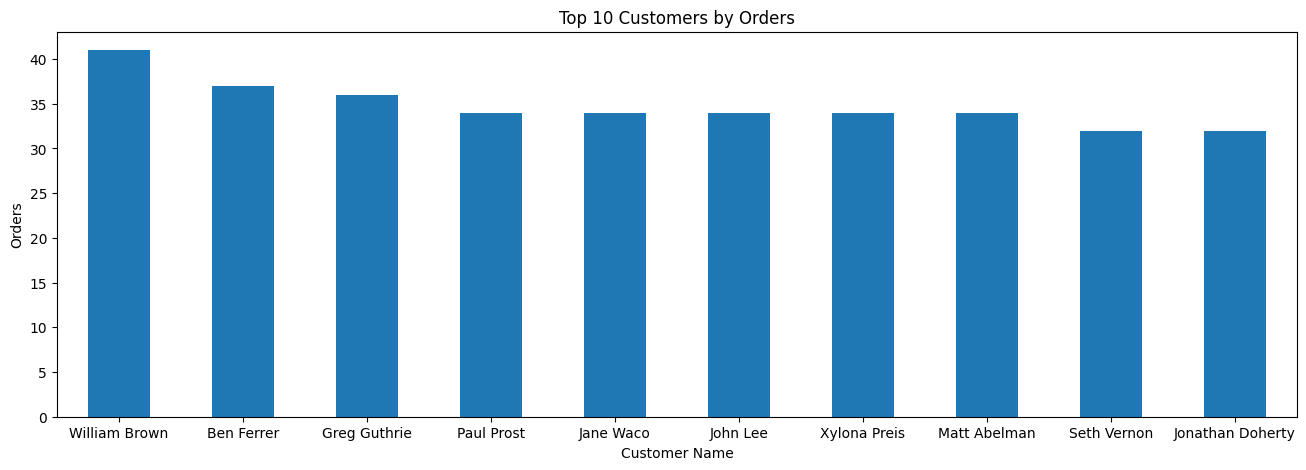

In [208]:
plt.figure(figsize=(16,5))
Most_Orders_Customer.plot(kind="bar")
plt.title("Top 10 Customers by Orders")
plt.xlabel("Customer Name")
plt.ylabel("Orders")
plt.xticks(rotation=0)
plt.show()

# **Finding**

William Brown had the highest number of orders among the top 10 customers, with 41 orders. Ben Ferrer ranked second with 37 orders, while Seth Vernon and Jonathan Doherty had the lowest count among the top 10, with 32 orders each.

# **Business Insight**

These customers demonstrate relatively frequent purchasing behavior. The company should identify what drives their repeat purchases and use similar strategies to encourage other customers to order more frequently.

In [209]:
Best_Cities=df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(10)
Best_Cities

,Sales
City,
New York City,"256,368.16"
Los Angeles,"175,851.34"
Seattle,"119,540.74"
San Francisco,"112,669.09"
Philadelphia,"109,077.01"
Houston,"64,504.76"
Chicago,"48,539.54"
San Diego,"47,521.03"
Jacksonville,"44,713.18"


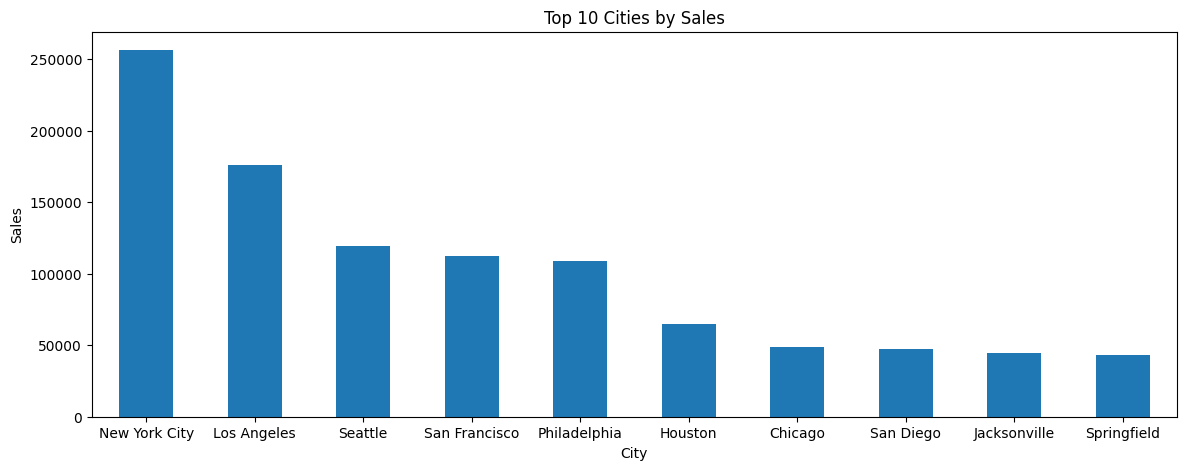

In [210]:
plt.figure(figsize=(14,5))
Best_Cities.plot(kind="bar")
plt.title("Top 10 Cities by Sales")
plt.xlabel("City")
plt.ylabel("Sales")
plt.xticks(rotation=0)
#plt.tight_layout()
plt.show()

# **Finding**

New York City generated the highest sales among the top 10 cities, followed by Los Angeles. Seattle, San Francisco, and Philadelphia also showed relatively strong sales, while Springfield had the lowest sales among the top 10 cities.

# **Business Insight**

Sales are heavily concentrated in a few major cities, with New York City significantly outperforming the other cities. The company should investigate what drives this strong performance and evaluate whether similar strategies can be applied to lower-performing cities.

In [211]:
pd.set_option("display.float_format", "{:,.2f}".format)
Segment_Sales=df.groupby('Segment')['Sales'].sum()
Segment_Sales

,Sales
Segment,
Consumer,"1,170,659.79"
Corporate,"715,806.13"
Home Office,"440,068.43"


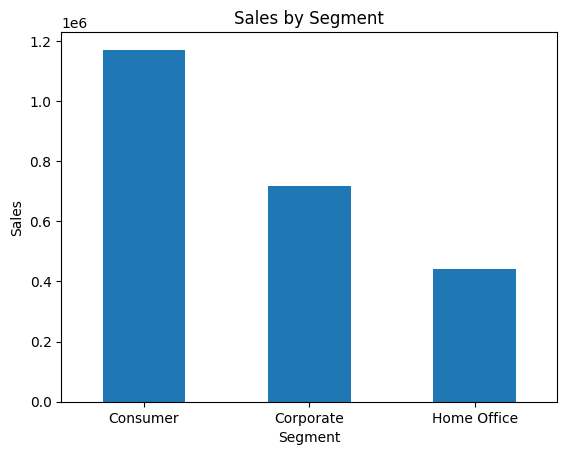

In [212]:
Segment_Sales.plot(kind="bar")
plt.title("Sales by Segment")
plt.xlabel("Segment")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.show()

# **Finding**

The Consumer segment generated the highest total sales, followed by the Corporate segment. The Home Office segment generated the lowest total sales.

# **Business Insight**

The Consumer segment is the company's strongest revenue contributor by a significant margin. The company should investigate what drives Consumer-segment sales and determine whether successful strategies can be applied to the Corporate and Home Office segments.

# **##PRODUCT ANALYSIS##**

In [213]:
Product_Sales=df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
Product_Sales

,Sales
Product Name,
Canon imageCLASS 2200 Advanced Copier,"61,599.82"
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,"27,453.38"
Cisco TelePresence System EX90 Videoconferencing Unit,"22,638.48"
HON 5400 Series Task Chairs for Big and Tall,"21,870.58"
GBC DocuBind TL300 Electric Binding System,"19,823.48"
GBC Ibimaster 500 Manual ProClick Binding System,"19,024.50"
Hewlett Packard LaserJet 3310 Copier,"18,839.69"
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color","18,374.90"
GBC DocuBind P400 Electric Binding System,"17,965.07"


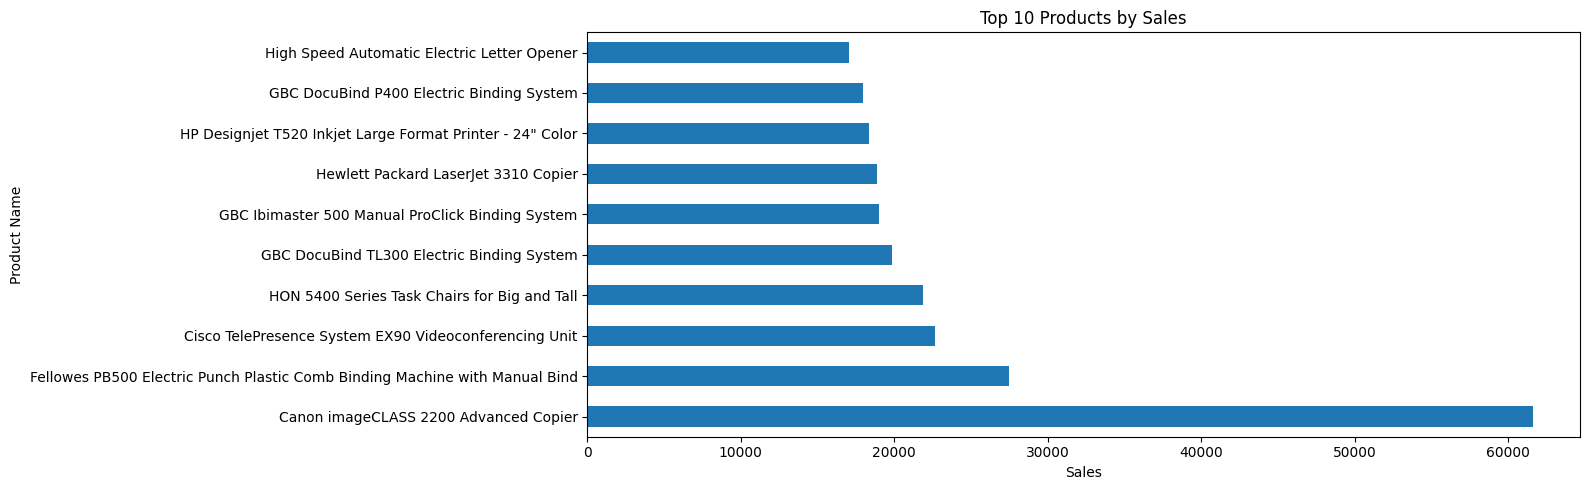

In [214]:
plt.figure(figsize=(16,5))
Product_Sales.plot(kind="barh")
plt.title("Top 10 Products by Sales")
plt.ylabel("Product Name")
plt.xlabel("Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# **Findings**

* The chart highlights the 10 products generating the highest total sales.
* Canon imageCLASS 2200 Advanced Copier is the strongest revenue-generating product by a large margin.
* The remaining top-performing products generate considerably lower sales compared with the leading product.

# **Business Insight**

The business should prioritize its highest-revenue products through reliable inventory, competitive pricing, and focused sales efforts. However, high sales alone don’t necessarily mean high profitability, so these products should also be evaluated using Profit and Profit Margin % before making pricing or inventory decisions.

In [215]:
Rare_Products=df.groupby('Product Name')['Quantity'].sum().sort_values(ascending=True).head(10)
Rare_Products

,Quantity
Product Name,
Xerox 20,1
"Bush Saratoga Collection 5-Shelf Bookcase, Hanover Cherry, *Special Order",1
Boston 1900 Electric Pencil Sharpener,1
Global Enterprise Series Seating Low-Back Swivel/Tilt Chairs,1
Penpower WorldCard Pro Card Scanner,1
Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac,2
Canon imageCLASS MF7460 Monochrome Digital Laser Multifunction Copier,2
Xerox 1984,2
Xerox 1969,2


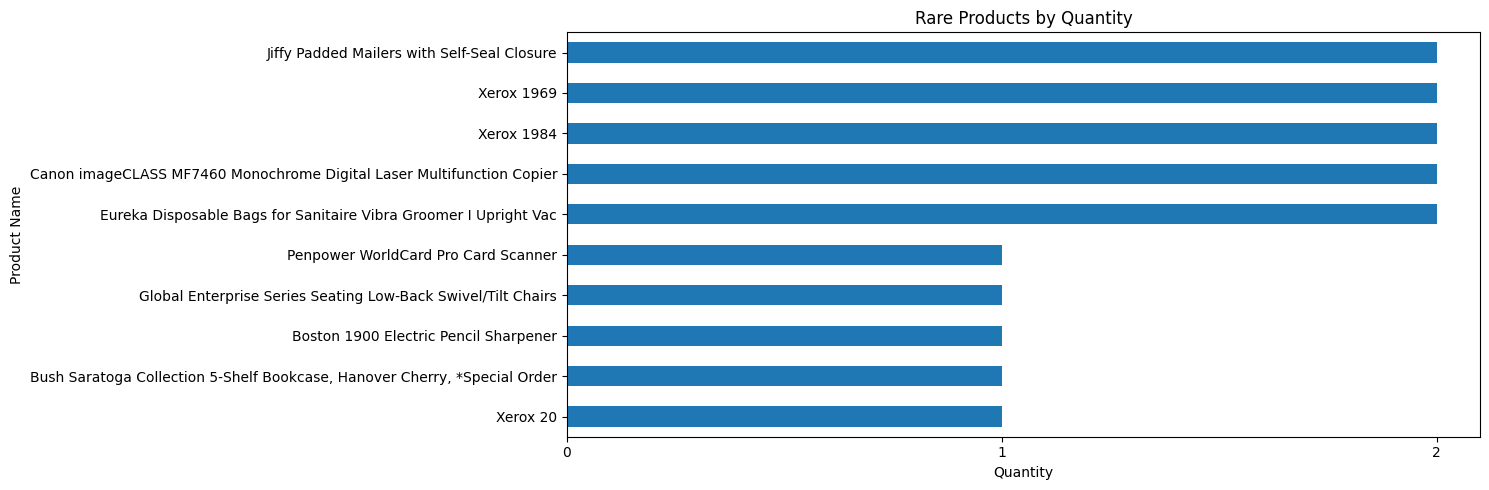

In [216]:
plt.figure(figsize=(15,5))
Rare_Products.plot(kind="barh")
plt.title("Rare Products by Quantity")
plt.ylabel("Product Name")
plt.xlabel("Quantity")
plt.xticks(rotation=0)
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

# **Findings**

* The analysis identifies the 10 products with the lowest total quantities sold.
* Several products have a total quantity of only 1–2 units, indicating extremely low demand.
* These products may have limited customer demand compared with the rest of the product catalog.

# **Business Insight**

Products with consistently low sales volume may lead to excess inventory and storage costs. The business should review these products before restocking and consider reducing inventory, changing pricing, or discontinuing them if the low demand persists.

In [217]:
Product_Sales_Quantity=df.groupby('Product Name')[['Sales','Quantity']].sum()
Product_Sales_Quantity

,Sales,Quantity
Product Name,,
"""While you Were Out"" Message Book, One Form per Page",25.23,8
"#10 Gummed Flap White Envelopes, 100/Box",41.30,11
#10 Self-Seal White Envelopes,108.68,10
"#10 White Business Envelopes,4 1/8 x 9 1/2",488.90,32
"#10- 4 1/8"" x 9 1/2"" Recycled Envelopes",286.67,37
...,...,...
"iKross Bluetooth Portable Keyboard + Cell Phone Stand Holder + Brush for Apple iPhone 5S 5C 5, 4S 4","1,315.66",64
iOttie HLCRIO102 Car Mount,215.89,12
iOttie XL Car Mount,223.89,14


In [218]:
Sales_Threshold=Product_Sales_Quantity['Sales'].median()
Quantity_Threshold=Product_Sales_Quantity['Quantity'].median()
print("Sales Threshold:",Sales_Threshold)
print("Quantity Threshold:",Quantity_Threshold)

Sales Threshold: 321.846
Quantity Threshold: 19.0


In [219]:
Product_High_Sales_Low_Quantity=Product_Sales_Quantity[(Product_Sales_Quantity['Sales']>Sales_Threshold) & (Product_Sales_Quantity['Quantity']<Quantity_Threshold)]
Product_High_Sales_Low_Quantity=Product_High_Sales_Low_Quantity.sort_values(by='Sales',ascending=False).head(10)
Product_High_Sales_Low_Quantity

,Sales,Quantity
Product Name,,
Cisco TelePresence System EX90 Videoconferencing Unit,"22,638.48",6
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color","18,374.90",12
High Speed Automatic Electric Letter Opener,"17,030.31",11
Lexmark MX611dhe Monochrome Laser Printer,"16,829.90",18
Ibico EPK-21 Electric Binding System,"15,875.92",13
"3D Systems Cube Printer, 2nd Generation, Magenta","14,299.89",11
Cubify CubeX 3D Printer Double Head Print,"11,099.96",9
Bady BDG101FRU Card Printer,"9,279.88",14
Canon Imageclass D680 Copier / Fax,"8,959.87",16


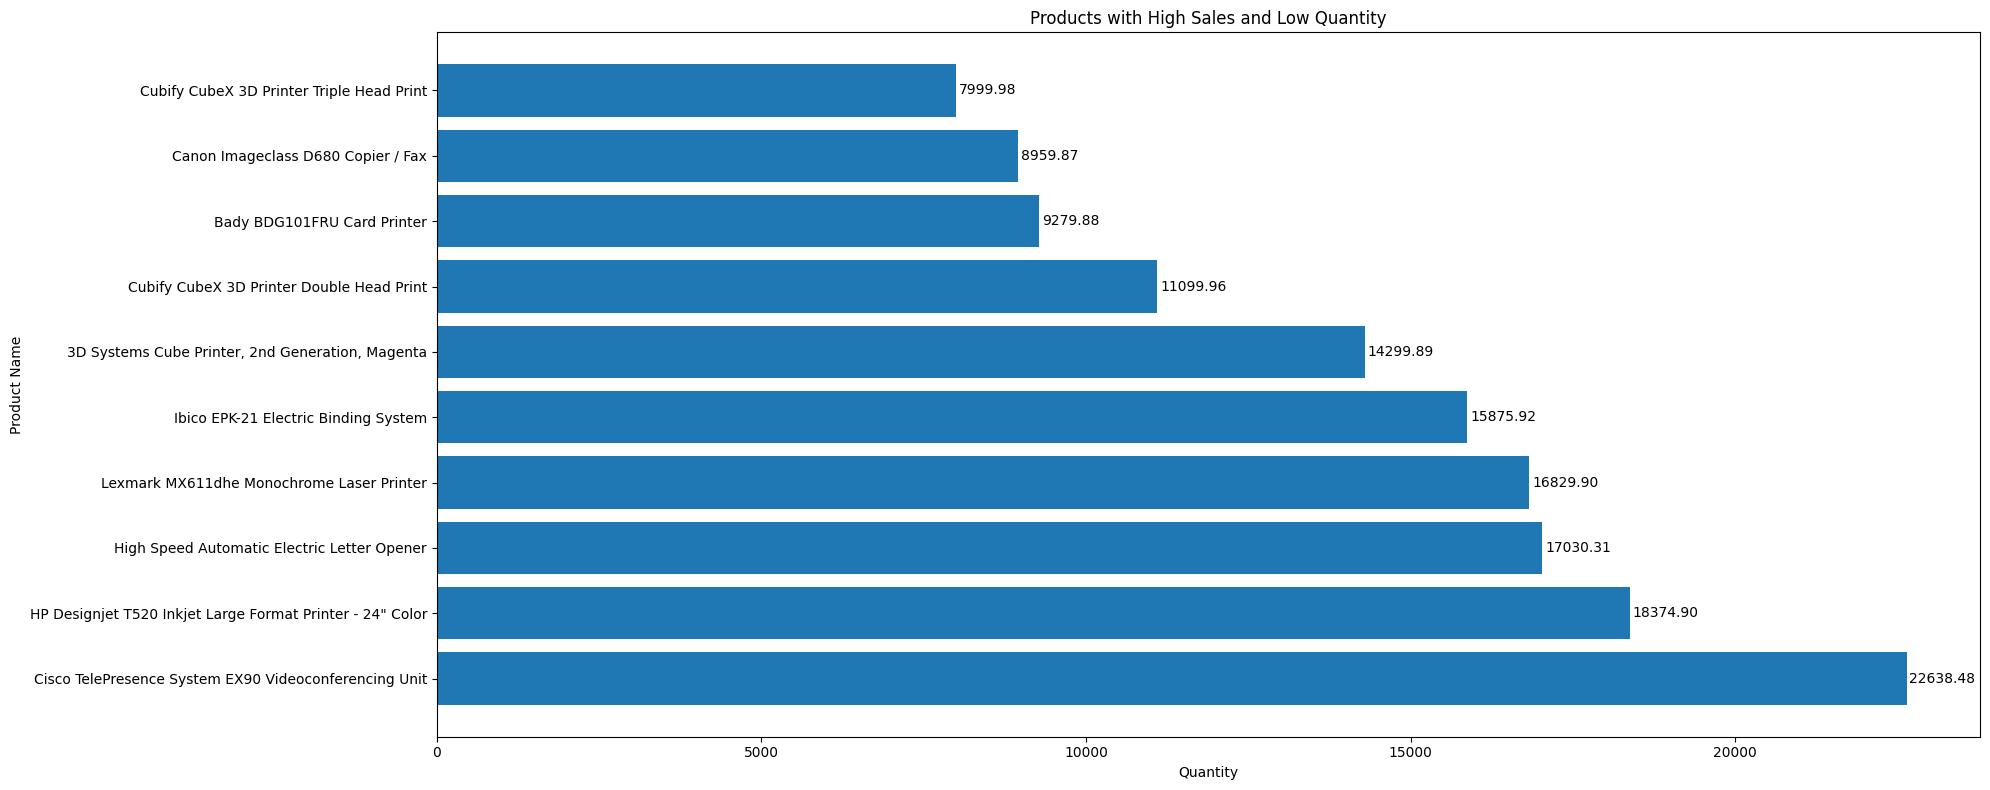

In [220]:
plt.figure(figsize=(20,8))
bars=plt.barh(Product_High_Sales_Low_Quantity.index,Product_High_Sales_Low_Quantity['Sales'])
plt.title("Products with High Sales and Low Quantity")
plt.xlabel("Quantity")
plt.ylabel("Product Name")
plt.bar_label(bars, fmt='%.2f', padding=2)
plt.tight_layout()
plt.show()

# **Findings**

* The chart highlights the 10 products generating the highest sales despite relatively low quantities sold.
* These products generate substantial revenue from comparatively fewer units sold.
* This pattern suggests that these are likely high-value products with higher revenue per unit.

# **Business Insight**

Products with high sales but low quantities can be high-value revenue drivers. The business should prioritize maintaining their availability, pricing them appropriately, and ensuring sufficient inventory rather than assuming low quantity means weak performance.

In [221]:
Product_Sales_Quantity_Profit=df.groupby('Product Name')[['Sales','Quantity','Profit_Margin %']].sum()
Product_Sales_Quantity_Profit

,Sales,Quantity,Profit_Margin %
Product Name,,,
"""While you Were Out"" Message Book, One Form per Page",25.23,8,125.00
"#10 Gummed Flap White Envelopes, 100/Box",41.30,11,157.00
#10 Self-Seal White Envelopes,108.68,10,183.25
"#10 White Business Envelopes,4 1/8 x 9 1/2",488.90,32,302.50
"#10- 4 1/8"" x 9 1/2"" Recycled Envelopes",286.67,37,417.00
...,...,...,...
"iKross Bluetooth Portable Keyboard + Cell Phone Stand Holder + Brush for Apple iPhone 5S 5C 5, 4S 4","1,315.66",64,216.00
iOttie HLCRIO102 Car Mount,215.89,12,-85.83
iOttie XL Car Mount,223.89,14,-45.00


In [222]:
Products_To_Discontinue=Product_Sales_Quantity_Profit[(Product_Sales_Quantity_Profit['Profit_Margin %']<0) & (Product_Sales_Quantity_Profit['Quantity']<Quantity_Threshold) & (Product_Sales_Quantity_Profit['Sales']<Sales_Threshold)]
Products_To_Discontinue=Products_To_Discontinue.sort_values(by='Profit_Margin %',ascending=True).head(10)
Products_To_Discontinue=Products_To_Discontinue.sort_values(by='Profit_Margin %',ascending=False)
Products_To_Discontinue

,Sales,Quantity,Profit_Margin %
Product Name,,,
Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac,1.62,2,-275.00
GBC Standard Plastic Binding Systems Combs,55.75,13,-294.75
Binder Posts,57.40,16,-309.00
GBC Linen Binding Covers,207.57,18,-310.00
Acco Economy Flexible Poly Round Ring Binder,11.48,6,-310.42
UniKeep View Case Binders,28.85,13,-341.50
"Commercial WindTunnel Clean Air Upright Vacuum, Replacement Belts, Filtration Bags",50.57,17,-410.00
Belkin F9S820V06 8 Outlet Surge,266.34,17,-440.00
Insertable Tab Indexes For Data Binders,17.49,13,-454.00


In [223]:
Products_To_Discontinue.drop(columns=['Quantity','Sales'],inplace=True)

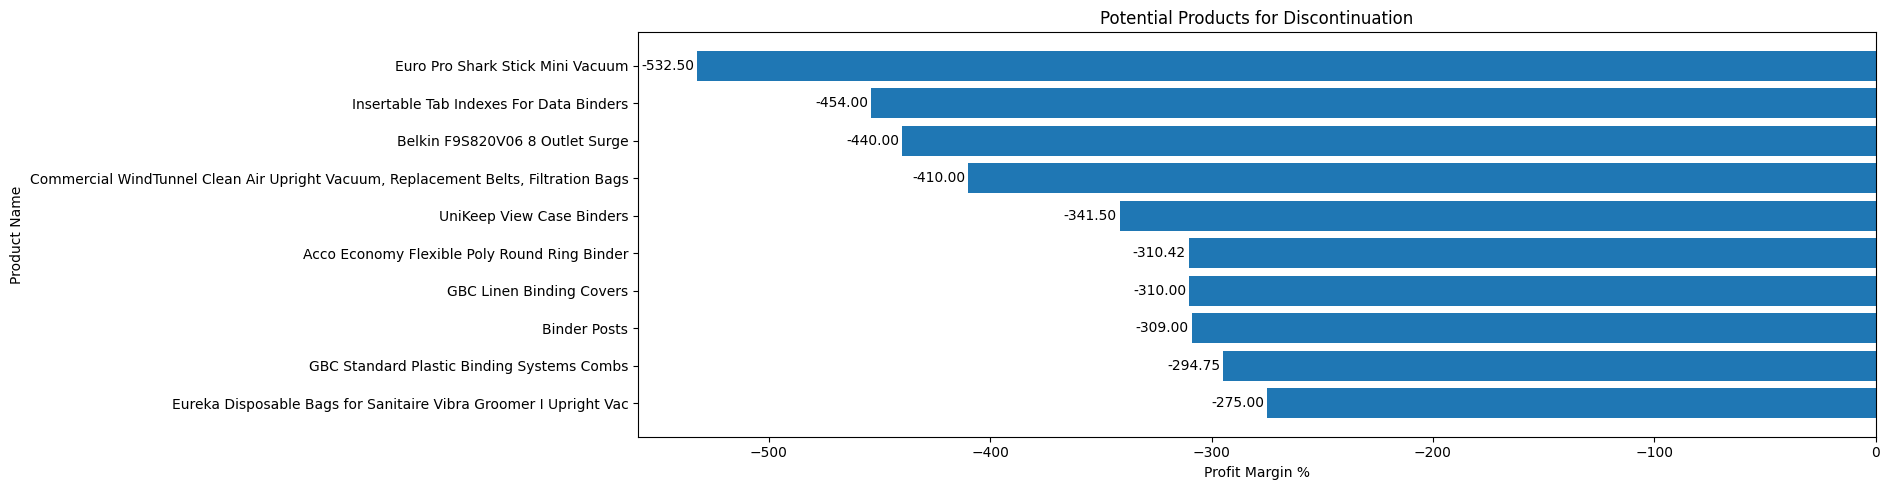

In [224]:
plt.figure(figsize=(19,5))
bars=plt.barh(Products_To_Discontinue.index,Products_To_Discontinue['Profit_Margin %'])
plt.title("Potential Products for Discontinuation")
plt.xlabel("Profit Margin %")
plt.ylabel("Product Name")
plt.bar_label(bars, fmt='%.2f', padding=2)
plt.tight_layout()
plt.show()

# **Findings**

* 485 products have a negative profit margin.
* After applying the low-sales and low-quantity criteria, the analysis identifies products that may be underperforming.
* The chart highlights the 10 products with the lowest profit margins, with some showing extremely high negative margins.

# **Business Insight**

Products with low demand, low sales, and negative profitability are potential candidates for discontinuation. However, these products should be investigated before removal to determine whether high discounts, pricing issues, or unusually high costs are causing the losses.

# **##REGIONAL ANALYSIS##**

In [225]:
Region_Performance=df.groupby('Region')['Sales'].sum()
Region_Performance

,Sales
Region,
Central,"503,170.67"
East,"691,828.17"
South,"391,721.91"
West,"739,813.61"


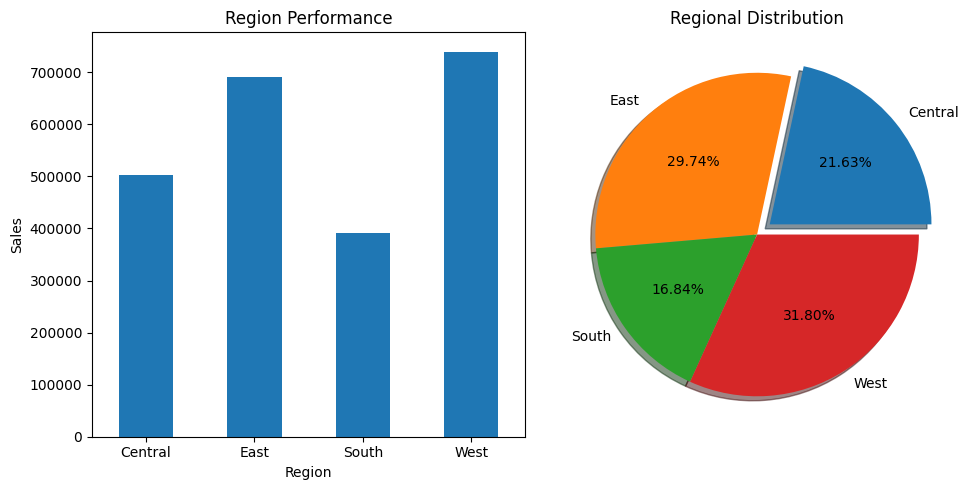

In [226]:
figure,axis=plt.subplots(1,2,figsize=(10,5))
Region_Performance.plot(kind="bar",ax=axis[0])
axis[0].set_title("Region Performance")
axis[0].set_xlabel("Region")
axis[0].set_ylabel("Sales")
axis[0].tick_params(axis='x',rotation=0)
explode=(0.1,0,0,0)
plt.pie(Region_Performance,labels=Region_Performance.index,explode=explode,autopct="%1.2f%%",shadow=True)
axis[1].set_title("Regional Distribution")
plt.tight_layout()
plt.show()
plt.show()

# **Findings**

* West generates the highest total sales among the four regions.
* East is the second-highest contributor to overall sales.
* South has the lowest total sales contribution.
* The regional distribution shows that West and East together account for the majority of sales.

# **Business Insight**

* The business is heavily dependent on West and East, so these regions should remain key markets for revenue growth.
* South underperforms in total sales, making it a region worth investigating for weaker demand, customer reach, pricing, or product mix.
* The gap between regions suggests that regional strategies should not be identical—South may need targeted improvements rather than the same approach used in West/East.

In [227]:
Region_AOV=df.groupby('Region').agg(Tot_Sales=('Sales','sum'),Total_Orders=('Order ID','nunique'))
Region_AOV['AOV']=Region_AOV['Tot_Sales']/Region_AOV['Total_Orders']
Region_AOV=Region_AOV.sort_values(by='AOV',ascending=False)
Region_AOV

,Tot_Sales,Total_Orders,AOV
Region,,,
South,"391,721.91",822,476.55
East,"691,828.17",1475,469.04
West,"739,813.61",1635,452.49
Central,"503,170.67",1179,426.78


In [228]:
Region_AOV.drop(columns=['Tot_Sales','Total_Orders'],inplace=True)
Region_AOV

,AOV
Region,
South,476.55
East,469.04
West,452.49
Central,426.78


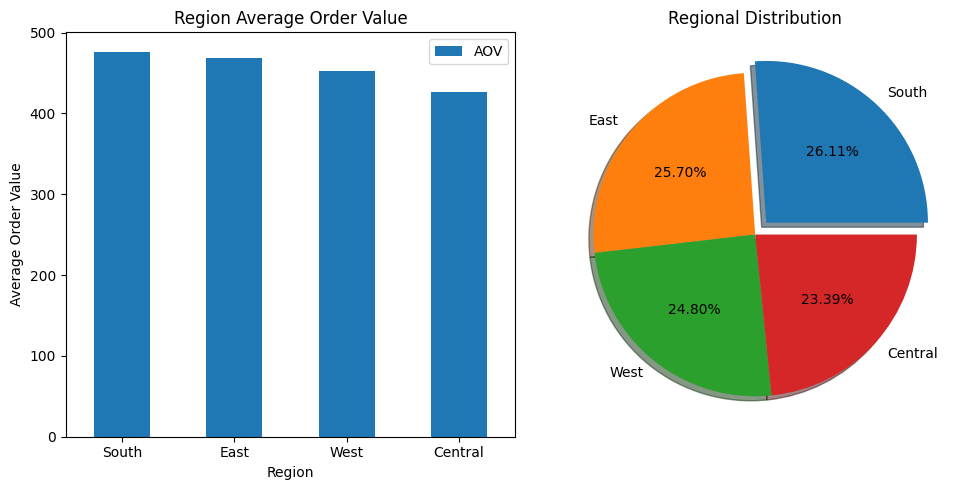

In [229]:
figure,axis=plt.subplots(1,2,figsize=(10,5))
Region_AOV.plot(kind="bar",ax=axis[0])
axis[0].set_title("Region Average Order Value")
axis[0].set_xlabel("Region")
axis[0].set_ylabel("Average Order Value")
axis[0].tick_params(axis='x',rotation=0)
explode=(0.1,0,0,0)
plt.pie(Region_AOV['AOV'],labels=Region_AOV.index,explode=explode,autopct="%1.2f%%",shadow=True)
axis[1].set_title("Regional Distribution")
plt.tight_layout()
plt.show()
plt.show()

# **Findings**

* South has the highest Average Order Value, at roughly ₹480.
* East follows closely at roughly ₹470.
* West is around ₹450.
* Central has the lowest AOV, at roughly ₹425.
* The differences aren’t huge, but South clearly leads.

# **Business Insight**

* South generates the highest-value orders on average, so it may have customers who purchase more expensive products or place larger orders.
* The business should investigate what drives South’s higher AOV—product mix, customer segment, pricing, or purchasing behavior—and see whether those strategies can be replicated elsewhere.
* Central’s lower AOV suggests an opportunity to increase order value through upselling, cross-selling, or better product bundling.

#**##PROFITABILITY##**

In [230]:
df.groupby("Product Name")["Profit"].sum().sort_values(ascending=False).head(10)

,Profit
Product Name,
Canon imageCLASS 2200 Advanced Copier,"25,199.93"
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,"7,753.04"
Hewlett Packard LaserJet 3310 Copier,"6,983.88"
Canon PC1060 Personal Laser Copier,"4,570.93"
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color","4,094.98"
Ativa V4110MDD Micro-Cut Shredder,"3,772.95"
"3D Systems Cube Printer, 2nd Generation, Magenta","3,717.97"
Plantronics Savi W720 Multi-Device Wireless Headset System,"3,696.28"
Ibico EPK-21 Electric Binding System,"3,345.28"


# **Findings**

* The analysis identifies the products generating the highest total profit.
* Canon imageCLASS 2200 Advanced Copier is the highest-profit product, generating approximately $25,200 in profit.
* The remaining top-performing products generate substantially lower profits, with Fellowes PB500 Electric Punch ranking second.

# **Business Insight**

* Profitability is concentrated among a relatively small number of products.
* High-profit products can be useful for understanding which products contribute disproportionately to overall profitability.
* Profit should be considered alongside sales volume, since a product generating high sales does not necessarily generate high profit.

In [231]:
Products_To_Discontinue.sort_values(by='Profit_Margin %',ascending=True)

,Profit_Margin %
Product Name,
Euro Pro Shark Stick Mini Vacuum,-532.50
Insertable Tab Indexes For Data Binders,-454.00
Belkin F9S820V06 8 Outlet Surge,-440.00
"Commercial WindTunnel Clean Air Upright Vacuum, Replacement Belts, Filtration Bags",-410.00
UniKeep View Case Binders,-341.50
Acco Economy Flexible Poly Round Ring Binder,-310.42
GBC Linen Binding Covers,-310.00
Binder Posts,-309.00
GBC Standard Plastic Binding Systems Combs,-294.75


# **Findings**

* The analysis identifies the 10 products with the lowest profit margins.
* Euro Pro Shark Stick Mini Vacuum has the lowest profit margin at −532.50%.
* All 10 identified products have negative profit margins, meaning they are generating losses relative to their sales.

# **Business Insight**

* These products are potential candidates for discontinuation or pricing/cost review because they are currently loss-making.
* The extremely negative margins indicate that some products may have high costs or excessive discounts relative to their sales.
* However, negative margin alone doesn’t automatically mean discontinue; these products should be investigated before making that decision.

In [232]:
Category_Profit_Margin=df.groupby('Category')[['Sales', 'Profit']].sum()
Category_Profit_Margin['Profit_Margin %']=(Category_Profit_Margin['Profit']/Category_Profit_Margin['Sales'])*100
Category_Profit_Margin = Category_Profit_Margin.sort_values('Profit_Margin %',ascending=False)
Category_Profit_Margin

,Sales,Profit,Profit_Margin %
Category,,,
Technology,"839,893.28","146,543.38",17.45
Office Supplies,"731,893.31","126,023.44",17.22
Furniture,"754,747.76","19,730.00",2.61


# **Findings**

* Technology has the highest profit margin at 17.45%.
* Office Supplies is very close at 17.22%.
* Furniture has a significantly lower profit margin of only 2.61%.
* All three categories are profitable, but Furniture generates considerably less profit relative to its sales.

# **Business Insight**

* Technology and Office Supplies are the strongest categories in terms of profitability.
* Furniture is the weakest category by profit margin, suggesting that its pricing, discounts, or costs may need closer analysis.
* High sales alone don’t necessarily mean high profitability—Furniture demonstrates that clearly.